<a href="https://colab.research.google.com/github/leippold/finance-nlp-workshop/blob/main/colabs/rlhf_dpo_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alignment is a tilt — RLHF, DPO and Goodhart, computed exactly

**DEEP Learning Summer School 2026 · Session 2 · §III (post-training)**

The lecture derived four results and asserted their consequences: the optimal
KL-regularized policy is an **exponential tilt** $\pi^\star \propto
\pi_{\text{ref}}\,e^{r/\beta}$; $\beta$ **prices** divergence rather than
setting it; optimizing a **fitted** reward eventually destroys the true one;
and best-of-$n$ carries a closed-form KL ceiling $\log n - \tfrac{n-1}{n}$.
On a real language model every one of these is invisible — the response space
is astronomically large, so everything becomes a sampling estimate.

This notebook makes the space **small enough to enumerate** (a tiny "analyst"
that writes four-token risk statements: $8^4 = 4096$ possible responses), so
every object in §III is **computed, not sketched**: the tilt is exact, the KL
is exact, the Goodhart curve is measured, best-of-$n$'s distribution is exact,
and DPO's fixed point can be compared to the closed form it is supposed to
reach. Runs on CPU in about a minute; only the optional §8 (a real GPT-2
distribution, tilted exactly) wants the internet.

**Predict before you run.**
1. Best-of-16 selection: how many nats of divergence, at most? (§6 checks.)
2. As $\beta \to 0$ the *proxy* reward rises monotonically. Does the *true*
   reward? Where does it turn? (§5 measures.)
3. DPO never samples. For statements that appear in **no** preference pair,
   what does its implicit reward do? (§7b plots exactly that.)

## 1 · The world: a tiny analyst with an enumerable mouth

Eight tokens, four-token statements. The reference policy $\pi_{\text{ref}}$
is a smoothed bigram model fitted on a small "house style" corpus — prudent,
hedged, a little dull. Because $|\mathcal{Y}| = 4096$, $\pi_{\text{ref}}(y)$
is a vector we can hold in one array, and every expectation below is a dot
product, not a Monte Carlo estimate.

In [1]:
import itertools, math
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
RUN_HUGGINGFACE = False      # section 8: tilt a real GPT-2 distribution (needs internet)

# house palette
PRUSSIAN, STEEL, MUTED, GOLD, RULE = "#22577D", "#5E92B5", "#6C6457", "#B5862E", "#D9D0C0"
plt.rcParams.update({"figure.facecolor": "white", "axes.edgecolor": RULE,
                     "axes.labelcolor": "#1B1915", "font.size": 11})

VOCAB = ["risk", "rising", "falling", "stable", "hedge", "hold", "buy", "strongly"]
L, V = 4, len(VOCAB)
STMTS = list(itertools.product(range(V), repeat=L))          # all 4096 statements
N_Y = len(STMTS)
def words(y): return " ".join(VOCAB[t] for t in y)

# the house-style corpus pi_ref is estimated from
house = [
    "risk rising hedge hold", "risk rising hedge buy", "risk stable hold hold",
    "risk falling buy hold",  "risk stable hedge hold", "risk rising hold hedge",
    "stable risk hold buy",   "rising risk hedge hold", "risk falling hold buy",
    "hedge risk rising hold", "risk stable buy hold",   "falling risk buy hedge",
    "risk rising hedge hedge","stable risk buy hold",   "risk hold stable hold",
]
BOS, K_SMOOTH = V, 0.1
uni = np.zeros((V + 1, V));
for line in house:
    ids = [VOCAB.index(w) for w in line.split()]
    prev = BOS
    for t in ids:
        uni[prev, t] += 1; prev = t
trans = (uni + K_SMOOTH) / (uni + K_SMOOTH).sum(1, keepdims=True)

log_pref = np.array([sum(math.log(trans[p, t]) for p, t in zip((BOS,) + y[:-1], y))
                     for y in STMTS])
pi_ref = np.exp(log_pref); pi_ref /= pi_ref.sum()

ent = -(pi_ref * np.log(pi_ref)).sum()
print(f"|Y| = {N_Y} statements   H(pi_ref) = {ent:.2f} nats "
      f"(uniform would be {math.log(N_Y):.2f})")
print("\nmost probable statements under the house style:")
for i in np.argsort(-pi_ref)[:8]:
    print(f"  {pi_ref[i]:.4f}   {words(STMTS[i])}")

|Y| = 4096 statements   H(pi_ref) = 5.83 nats (uniform would be 8.32)

most probable statements under the house style:
  0.0429   risk rising hedge hold
  0.0231   risk rising hold buy
  0.0199   risk hold buy hold
  0.0199   risk buy hold buy
  0.0159   risk falling buy hold
  0.0152   risk rising hedge buy
  0.0152   risk rising hedge risk
  0.0152   risk rising hedge hedge


## 2 · Two rewards: the truth, and a proxy fitted from comparisons

The world's true state is *risk is rising*. The **true reward** likes saying
so and likes hedging; it dislikes claiming the opposite and it pays nothing
for sounding confident:

$$r^\star(y) = 1.2\,[\text{rising} \in y] + 0.8\,[\text{hedge} \in y]
             - 1.2\,[\text{falling} \in y] - 0.5\,\#\text{strongly}(y).$$

and it charges an *accelerating* price for repetition — "hedge hedge hedge"
is waffle, and each extra repeat is worse than the last:
$-0.3\,\text{excess}(y)^2$, with excess = repeated slots.

Nobody observes $r^\star$. What we observe is what the lecture said we
observe: **comparisons**. Annotators see pairs of statements drawn from
$\pi_{\text{ref}}$ and pick a winner through Bradley–Terry noise,
$p(y \succ y') = \sigma(r^\star(y) - r^\star(y'))$. From those we fit a
reward model the way reward models are actually built: a function that
**generalizes through features** — here, linear in the eight token counts and
in excess. The family cannot represent the accelerating penalty; near the
reference distribution that hardly matters, which is exactly the trap: the
fit is good where the data lives and systematically wrong in a direction the
comparisons never probed hard. Hold that thought until §5.

3000 comparisons from pi_ref; fitted feature weights:
       risk: +0.01
     rising: +0.95
    falling: -1.01
     stable: -0.10
      hedge: +0.55
       hold: +0.06
        buy: +0.06
   strongly: -0.52
     excess: -0.59

the family is linear in excess; the truth charges -0.3*excess^2 -- so the fit is anchored where pi_ref lives (excess 0-2) and extrapolates too gently to excess = 3.


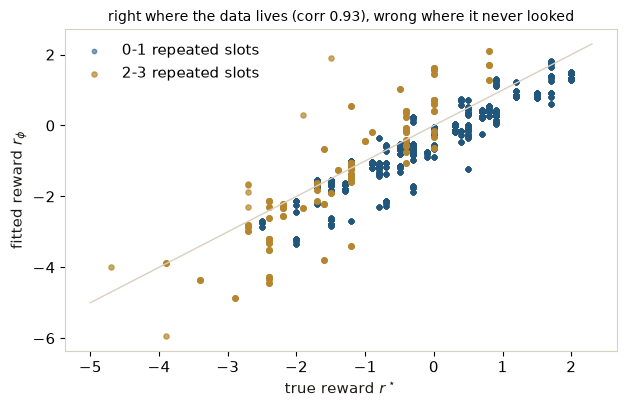

In [2]:
count = lambda y, w: sum(1 for t in y if VOCAB[t] == w)
has   = lambda y, w: float(count(y, w) > 0)
excess = np.array([L - len(set(y)) for y in STMTS])          # repeated slots, 0..3
r_true = np.array([1.2*has(y,"rising") + 0.8*has(y,"hedge")
                   - 1.2*has(y,"falling") - 0.5*count(y,"strongly") for y in STMTS]) \
         - 0.3 * excess**2
conf   = np.array([count(y,"strongly") + 0.5*has(y,"buy") for y in STMTS])

# feature map for every fitted reward below: 8 token counts + excess (linear)
F = np.zeros((N_Y, V + 1))
for i, y in enumerate(STMTS):
    for t in y: F[i, t] += 1
    F[i, V] = excess[i]
FEAT_NAMES = VOCAB + ["excess"]

def sample_comparisons(K, reward, sampler_p, rng):
    a = rng.choice(N_Y, size=K, p=sampler_p)
    b = rng.choice(N_Y, size=K, p=sampler_p)
    keep = a != b; a, b = a[keep], b[keep]
    p_a = 1/(1 + np.exp(-(reward[a] - reward[b])))
    win_a = rng.random(len(a)) < p_a
    return np.where(win_a, a, b), np.where(win_a, b, a)      # winners, losers

def fit_reward(winners, losers, steps=4000, lr=0.3, ridge=1e-3):
    # Bradley--Terry logistic regression in the feature family
    D = F[winners] - F[losers]
    w = np.zeros(F.shape[1])
    for _ in range(steps):
        m = 1/(1 + np.exp(-(D @ w)))
        w += lr * (D.T @ (1 - m) / len(D) - ridge * w)
    r = F @ w
    return r - r @ pi_ref, w                                 # identify: E_ref[r] = 0

K_COMP = 3000
winners, losers = sample_comparisons(K_COMP, r_true, pi_ref, rng)
r_phi, w_phi = fit_reward(winners, losers)

print(f"{K_COMP} comparisons from pi_ref; fitted feature weights:")
for name, w in zip(FEAT_NAMES, w_phi):
    print(f"  {name:>9}: {w:+.2f}")
print("\nthe family is linear in excess; the truth charges -0.3*excess^2 -- "
      "so the fit is anchored where pi_ref lives (excess 0-2) and extrapolates "
      "too gently to excess = 3.")

distinct = excess <= 1
cc_d = np.corrcoef(r_phi[distinct], r_true[distinct])[0,1]
fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.scatter(r_true[distinct],  r_phi[distinct], s=10, color=PRUSSIAN, alpha=.55,
           label="0-1 repeated slots")
ax.scatter(r_true[~distinct], r_phi[~distinct], s=14, color=GOLD, alpha=.7,
           label="2-3 repeated slots")
lim = [r_true.min() - .3, r_true.max() + .3]
ax.plot(lim, lim, color=RULE, lw=1)
ax.set_xlabel("true reward $r^\\star$"); ax.set_ylabel("fitted reward $r_\\phi$")
ax.legend(frameon=False)
ax.set_title(f"right where the data lives (corr {cc_d:.2f}), "
             "wrong where it never looked", fontsize=10)
plt.tight_layout(); plt.show()

## 3 · The Gibbs tilt, exactly — and verified against the objective

The lecture's proposition: the maximizer of
$\mathbb{E}_\pi[r] - \beta\,\mathrm{KL}(\pi \| \pi_{\text{ref}})$ is
$\pi_\beta(y) \propto \pi_{\text{ref}}(y)\, e^{r(y)/\beta}$. Here the
normalizer $Z$ is a sum over 4096 numbers, so we can *build* the optimum —
and then check the variational claim by throwing thousands of random
alternative policies at the objective. None of them should win.

In [3]:
def gibbs_tilt(r, beta):
    logw = np.log(pi_ref) + r / beta
    logw -= logw.max()
    p = np.exp(logw); return p / p.sum()

KL  = lambda p, q: float(np.sum(np.where(p > 0, p * (np.log(p + 1e-300) - np.log(q)), 0.0)))
OBJ = lambda p, r, beta: float(p @ r - beta * KL(p, pi_ref))

beta0 = 1.0
pi_b = gibbs_tilt(r_phi, beta0)
J_star = OBJ(pi_b, r_phi, beta0)

viol = 0
for _ in range(3000):                       # random alternatives: tilted + Dirichlet noise
    q = pi_b * rng.dirichlet(np.full(N_Y, 0.5)) if rng.random() < .5 \
        else rng.dirichlet(np.full(N_Y, rng.uniform(0.05, 5.0)))
    q = q / q.sum()
    if OBJ(q, r_phi, beta0) > J_star + 1e-9: viol += 1
print(f"beta = {beta0}: E[r] = {pi_b @ r_phi:+.3f}  KL = {KL(pi_b, pi_ref):.3f} nats  "
      f"objective = {J_star:+.4f}")
print(f"random alternative policies tried: 3000, objective violations: {viol}")
assert viol == 0

beta = 1.0: E[r] = +0.747  KL = 0.342 nats  objective = +0.4049
random alternative policies tried: 3000, objective violations: 0


## 4 · $\beta$ prices the KL — it does not set it

Same $\beta$, two reward shapes, two very different realized divergences: the
achieved KL depends on the *shape* of $r$, not on $\beta$ alone. And the pair
$(r, \beta)$ is only identified up to scale — rescale both and the policy does
not move. Conclusion from the lecture, now a number: **report the measured
KL**, not the multiplier.

two teams both report "beta = 0.3":
  peaked reward -> measured KL = 1.49 nats
  flat reward   -> measured KL = 0.17 nats
rescale (r, beta) -> (c r, c beta), c = 7.0: max |change in pi| = 1.30e-18


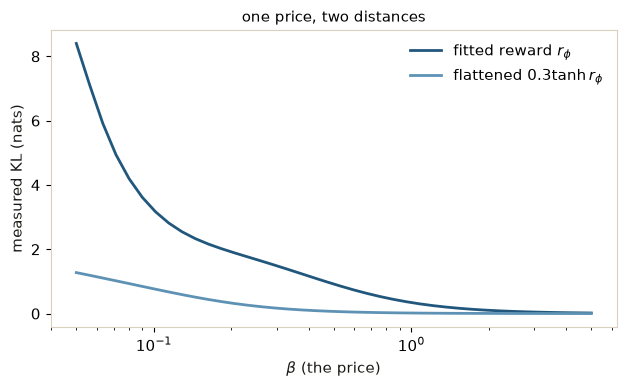

In [4]:
r_flat = 0.3 * np.tanh(r_phi)                        # same ordering, flattened shape
betas = np.geomspace(0.05, 5.0, 40)
kl_peaked = [KL(gibbs_tilt(r_phi, b), pi_ref) for b in betas]
kl_flat   = [KL(gibbs_tilt(r_flat, b), pi_ref) for b in betas]

b_show = 0.3
print(f'two teams both report "beta = {b_show}":')
print(f"  peaked reward -> measured KL = {KL(gibbs_tilt(r_phi, b_show), pi_ref):.2f} nats")
print(f"  flat reward   -> measured KL = {KL(gibbs_tilt(r_flat, b_show), pi_ref):.2f} nats")
c = 7.0
drift = np.abs(gibbs_tilt(c * r_phi, c * beta0) - gibbs_tilt(r_phi, beta0)).max()
print(f"rescale (r, beta) -> (c r, c beta), c = {c}: max |change in pi| = {drift:.2e}")

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(betas, kl_peaked, color=PRUSSIAN, lw=2, label="fitted reward $r_\\phi$")
ax.plot(betas, kl_flat,   color=STEEL,    lw=2, label="flattened $0.3\\tanh r_\\phi$")
ax.set_xscale("log"); ax.set_xlabel("$\\beta$ (the price)"); ax.set_ylabel("measured KL (nats)")
ax.legend(frameon=False); ax.set_title("one price, two distances", fontsize=11)
plt.tight_layout(); plt.show()

## 5 · The Goodhart curve, measured

Sweep $\beta$ downward — divergence gets cheaper and cheaper — and track two
numbers under the *exact* tilted policy: the proxy reward
$\mathbb{E}_{\pi_\beta}[r_\phi]$ (what the optimizer sees) and the true
reward $\mathbb{E}_{\pi_\beta}[r^\star]$ (what the world pays). The lecture's
stylized figure claimed the proxy keeps rising while the true reward turns,
because hard optimization finds the region where the *estimation error is
largest and positive*. Here that region is knowable in advance: the linear
family under-prices heavy repetition, so cheap divergence should buy
repetitive, high-count statements the truth scores badly. The claim is
testable — and so is the mechanism.

**Predict first:** at roughly what $\sqrt{\mathrm{KL}}$ does the true reward
peak — before or after the proxy has doubled its gain?

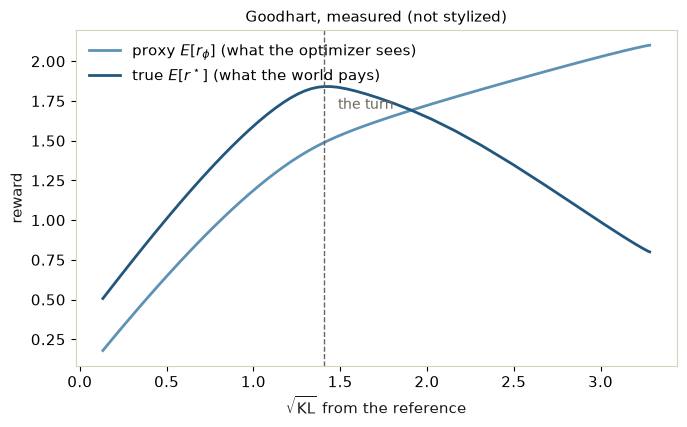

true reward peaks at sqrt(KL) = 1.41 (KL = 1.98 nats), then falls while the proxy keeps rising.

beta = 2.00  (gentle tilt) -- top statements:
  0.079  risk rising hedge hold       r_true = +2.00  r_phi = +1.45
  0.033  risk rising hold buy         r_true = +1.20  r_phi = +0.96
  0.028  risk rising hedge buy        r_true = +2.00  r_phi = +1.45

beta = 0.19  (near the true optimum) -- top statements:
  0.249  risk rising hedge hold       r_true = +2.00  r_phi = +1.45
  0.091  risk rising hedge buy        r_true = +2.00  r_phi = +1.45
  0.070  risk rising hold hedge       r_true = +2.00  r_phi = +1.45

beta = 0.02  (over-optimized) -- top statements:
  0.330  rising hedge rising rising   r_true = +0.80  r_phi = +2.10
  0.330  rising rising rising hedge   r_true = +0.80  r_phi = +2.10
  0.330  rising rising hedge rising   r_true = +0.80  r_phi = +2.10


In [5]:
betas_g = np.geomspace(5.0, 0.02, 60)
sweep = [(math.sqrt(KL(p := gibbs_tilt(r_phi, b), pi_ref)), p @ r_phi, p @ r_true)
         for b in betas_g]
x, proxy, true = map(np.array, zip(*sweep))
i_star = int(true.argmax())

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.plot(x, proxy, color=STEEL,    lw=2, label="proxy $E[r_\\phi]$ (what the optimizer sees)")
ax.plot(x, true,  color=PRUSSIAN, lw=2, label="true $E[r^\\star]$ (what the world pays)")
ax.axvline(x[i_star], color=MUTED, ls="--", lw=1)
ax.annotate("the turn", (x[i_star], true[i_star]), textcoords="offset points",
            xytext=(10, -16), color=MUTED, fontsize=10)
ax.set_xlabel("$\\sqrt{\\mathrm{KL}}$ from the reference"); ax.set_ylabel("reward")
ax.legend(frameon=False, loc="upper left")
ax.set_title("Goodhart, measured (not stylized)", fontsize=11)
plt.tight_layout(); plt.show()

print(f"true reward peaks at sqrt(KL) = {x[i_star]:.2f} "
      f"(KL = {x[i_star]**2:.2f} nats), then falls while the proxy keeps rising.")
for b, tag in [(2.0, "gentle tilt"), (float(betas_g[i_star]), "near the true optimum"),
               (0.02, "over-optimized")]:
    p = gibbs_tilt(r_phi, b)
    top = np.argsort(-p)[:3]
    print(f"\nbeta = {b:.2f}  ({tag}) -- top statements:")
    for i in top:
        print(f"  {p[i]:.3f}  {words(STMTS[i]):<28} r_true = {r_true[i]:+.2f}  r_phi = {r_phi[i]:+.2f}")

### 5b · What biased labels do to the tilt

The Goodhart turn above needs no bad intent — the annotators were *honest*
and the proxy still broke under pressure, purely from finite-sample error.
Now add the bias the lecture warned about: annotators who also reward
**confident-sounding** language, $r_{\text{ann}} = r^\star + 1.2\,
\text{conf}(y)$. Refit, tilt gently, and watch the house style change: the
policy learns to *sound certain* — which is precisely the pressure working
against the calibration Session 3 will need.

In [6]:
w2, l2 = sample_comparisons(K_COMP, r_true + 1.2 * conf, pi_ref, rng)
r_biased, _ = fit_reward(w2, l2)
b_show = 0.3
for tag, rr in [("honest annotators", r_phi), ("confidence-biased annotators", r_biased)]:
    p = gibbs_tilt(rr, b_show)
    top = np.argsort(-p)[:4]
    print(f"tilt at beta = {b_show}, {tag}:")
    for i in top:
        print(f"  {p[i]:.3f}  {words(STMTS[i]):<28} r_true = {r_true[i]:+.2f}")
    print()
print("same algebra, different measurement instrument: the deployed style is a "
      "property of who compared what.")

tilt at beta = 0.3, honest annotators:
  0.245  risk rising hedge hold       r_true = +2.00
  0.089  risk rising hedge buy        r_true = +2.00
  0.069  risk rising hold hedge       r_true = +2.00
  0.062  risk rising hedge hedge      r_true = +1.70

tilt at beta = 0.3, confidence-biased annotators:
  0.125  risk rising hedge hold       r_true = +2.00
  0.107  risk rising hedge buy        r_true = +2.00
  0.051  risk rising hold buy         r_true = +1.20
  0.050  risk rising hedge strongly   r_true = +1.50

same algebra, different measurement instrument: the deployed style is a property of who compared what.


## 6 · Best-of-$n$: the ceiling, checked — and put on the same axis

Sample $n$ statements from $\pi_{\text{ref}}$, keep the one the proxy scores
highest. No training happens, but the *induced* policy is not the reference —
and on an enumerable space its distribution is exact order statistics:
sort by score, then $P_{\text{BoN}}(y) = F(y)^n - F(y^-)^n$ with $F$ the
cumulative reference mass. The lecture's ceiling says
$\mathrm{KL} \le \log n - \frac{n-1}{n}$, with equality only in the
continuous case.

**Predict first:** $n=16$ — how close to the 1.84-nat ceiling does a
4096-atom space actually get?

   n  measured KL  ceiling log n-(n-1)/n
   2        0.193                  0.193
   4        0.636                  0.636
  16        1.830                  1.835
  64        3.147                  3.175


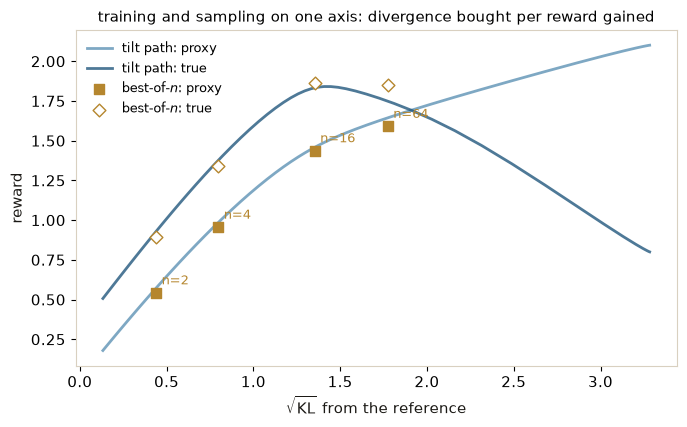

best-of-n sits below its ceiling (discrete atoms) and near the tilt path: two alignment methods, one currency.


In [7]:
def bon_dist(r, n):
    r = r + 1e-9 * rng.standard_normal(len(r))      # random tie-break among equal scores
    order = np.argsort(r, kind="stable")
    csum = np.cumsum(pi_ref[order])
    upper, lower = csum**n, np.concatenate([[0.0], csum[:-1]])**n
    p = np.empty(N_Y); p[order] = upper - lower
    return p

print(f"{'n':>4} {'measured KL':>12} {'ceiling log n-(n-1)/n':>22}")
bon_pts = []
for n in (2, 4, 16, 64):
    p = bon_dist(r_phi, n)
    kl_n = KL(p, pi_ref)
    bon_pts.append((math.sqrt(kl_n), p @ r_phi, p @ r_true))
    print(f"{n:>4} {kl_n:>12.3f} {math.log(n) - (n-1)/n:>22.3f}")

fig, ax = plt.subplots(figsize=(7.0, 4.4))
ax.plot(x, proxy, color=STEEL, lw=2, alpha=.8, label="tilt path: proxy")
ax.plot(x, true,  color=PRUSSIAN, lw=2, alpha=.8, label="tilt path: true")
bx, bp, bt = zip(*bon_pts)
ax.scatter(bx, bp, marker="s", s=42, color=GOLD, zorder=5, label="best-of-$n$: proxy")
ax.scatter(bx, bt, marker="D", s=42, facecolor="white", edgecolor=GOLD, zorder=5,
           label="best-of-$n$: true")
for (xx, pp, tt), n in zip(bon_pts, (2, 4, 16, 64)):
    ax.annotate(f"n={n}", (xx, pp), textcoords="offset points", xytext=(4, 6),
                fontsize=9, color=GOLD)
ax.set_xlabel("$\\sqrt{\\mathrm{KL}}$ from the reference"); ax.set_ylabel("reward")
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set_title("training and sampling on one axis: divergence bought per reward gained",
             fontsize=11)
plt.tight_layout(); plt.show()
print("best-of-n sits below its ceiling (discrete atoms) and near the tilt path: "
      "two alignment methods, one currency.")

## 7 · DPO, exactly — validate the shortcut on a planted world

DPO's claim is algebraic: substitute the tilt into Bradley–Terry, the
partition function cancels, and preference pairs train the policy directly.
Test the *fixed point* the honest way — plant a reward **inside a family the
policy can represent** (linear in our features), generate pairs from it with
full coverage, run the DPO objective on a policy of the form
$\pi_\theta \propto \pi_{\text{ref}}\, e^{F\theta}$, and compare the
result to the closed-form tilt it inverts. The same discipline as the planted
corpora in the other notebooks: never point an instrument at the world before
it has found a planted answer. (§7b then removes the safety net: an
*unrestricted* policy — one logit per statement, the LLM analogue — on
realistically sampled pairs.)

In [8]:
def train_dpo(winners, losers, beta_dpo, steps=4000, lr=1.0):
    theta = np.log(pi_ref).copy()                     # init at the reference
    for _ in range(steps):
        logp = theta - theta.max(); logp -= math.log(np.exp(logp).sum())
        h = beta_dpo * ((logp[winners] - np.log(pi_ref[winners]))
                        - (logp[losers] - np.log(pi_ref[losers])))
        m = 1/(1 + np.exp(-h))                        # sigma(implicit margin)
        g = np.zeros(N_Y)
        np.add.at(g, winners, (1 - m)); np.add.at(g, losers, -(1 - m))
        # gradient of mean log-sigmoid through the softmax
        gm = beta_dpo * g / len(winners)
        p = np.exp(logp)
        theta += lr * (gm - p * gm.sum())
    logp = theta - theta.max()
    p = np.exp(logp); return p / p.sum(), theta

BETA_DPO = 0.5
w_plant = np.array([0.5, 1.0, -0.8, 0.2, 0.6, 0.1, -0.3, -0.6, -0.4])
r_plant = F @ w_plant; r_plant -= r_plant @ pi_ref
uniform = np.full(N_Y, 1/N_Y)
wp, lp = sample_comparisons(20_000, r_plant, uniform, rng)  # planted: known reward, full coverage

def train_dpo_features(winners, losers, beta_dpo, steps=6000, lr=0.4):
    D = F[winners] - F[losers]
    th = np.zeros(F.shape[1])
    for _ in range(steps):
        m = 1/(1 + np.exp(-beta_dpo * (D @ th)))
        th += lr * beta_dpo * (D.T @ (1 - m)) / len(D)
    logw = np.log(pi_ref) + F @ th; logw -= logw.max()
    p = np.exp(logw); return p / p.sum(), th

pi_dpo, th_hat = train_dpo_features(wp, lp, BETA_DPO)
pi_star = gibbs_tilt(r_plant, BETA_DPO)
kl_gap = KL(pi_dpo, pi_star)

# gauge: the eight count features sum to 4 on every statement, so adding a
# constant to all count weights changes no comparison and no distribution --
# only RELATIVE count weights are identified (the Bradley--Terry
# identification fact, resurfacing in feature space). Compare gauge-fixed.
def gauge(w):
    w = w.copy(); w[:V] -= w[:V].mean(); return w
w_hat = gauge(BETA_DPO * th_hat); w_ref = gauge(w_plant)
w_err = np.abs(w_hat - w_ref).max()

print("planted vs recovered feature weights (gauge-fixed: count block centred):")
for name, wt, wh in zip(FEAT_NAMES, w_ref, w_hat):
    print(f"  {name:>9}: planted {wt:+.2f}   recovered {wh:+.2f}")
print(f"\nKL(pi_DPO || exact tilt of the planted reward) = {kl_gap:.5f} nats; "
      f"max gauge-fixed weight error = {w_err:.3f}")
ok = kl_gap < 0.01 and w_err < 0.05
print("DPO INSTRUMENT:", "VALIDATED -- the shortcut finds the closed form it inverts."
      if ok else "NOT VALIDATED -- do not interpret section 7b until this passes.")

planted vs recovered feature weights (gauge-fixed: count block centred):
       risk: planted +0.41   recovered +0.41
     rising: planted +0.91   recovered +0.91
    falling: planted -0.89   recovered -0.86
     stable: planted +0.11   recovered +0.13
      hedge: planted +0.51   recovered +0.51
       hold: planted +0.01   recovered +0.02
        buy: planted -0.39   recovered -0.39
   strongly: planted -0.69   recovered -0.72
     excess: planted -0.40   recovered -0.40

KL(pi_DPO || exact tilt of the planted reward) = 0.00036 nats; max gauge-fixed weight error = 0.036
DPO INSTRUMENT: VALIDATED -- the shortcut finds the closed form it inverts.


### 7b · What the convenience costs: unconstrained where data is absent

Now remove the safety net: give the policy **unrestricted capacity** — one
logit per statement, the analogue of an LLM that can move any sequence's
probability — and feed it pairs drawn from $\pi_{\text{ref}}$, the only
place preference data ever comes from, and far fewer of them. The lecture's
cost, verbatim: *the loss only ever sees the fixed pairs, so $\pi_\theta$ is
unconstrained where no preference data exists.* Plot DPO's implicit reward
against the truth, colored by whether a statement ever appeared in a pair.

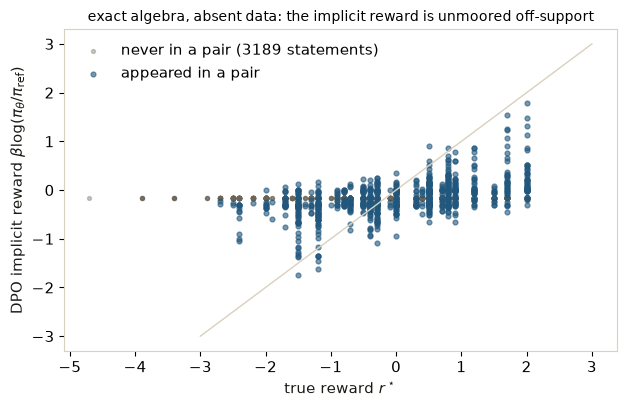

corr(implicit, true): 0.539 on covered statements, 0.004 off-support.
the cancellation removed a computation -- not the need for coverage.


In [9]:
def train_dpo(winners, losers, beta_dpo, steps=4000, lr=1.0):
    theta = np.log(pi_ref).copy()                     # unrestricted: one logit per statement
    for _ in range(steps):
        logp = theta - theta.max(); logp -= math.log(np.exp(logp).sum())
        h = beta_dpo * ((logp[winners] - np.log(pi_ref[winners]))
                        - (logp[losers] - np.log(pi_ref[losers])))
        m = 1/(1 + np.exp(-h))
        g = np.zeros(N_Y)
        np.add.at(g, winners, (1 - m)); np.add.at(g, losers, -(1 - m))
        theta += lr * beta_dpo * g / len(winners)
    logp = theta - theta.max()
    p = np.exp(logp); return p / p.sum(), theta

wr, lr_ = sample_comparisons(3000, r_true, pi_ref, rng)
pi_dpo2, _ = train_dpo(wr, lr_, BETA_DPO)
seen2 = np.bincount(np.concatenate([wr, lr_]), minlength=N_Y) > 0
impl2 = BETA_DPO * (np.log(pi_dpo2) - np.log(pi_ref)); impl2 -= impl2 @ pi_ref

fig, ax = plt.subplots(figsize=(6.4, 4.2))
ax.scatter(r_true[~seen2], impl2[~seen2], s=8,  color=MUTED, alpha=.35,
           label=f"never in a pair ({int((~seen2).sum())} statements)")
ax.scatter(r_true[seen2],  impl2[seen2],  s=12, color=PRUSSIAN, alpha=.6,
           label="appeared in a pair")
ax.plot([-3, 3], [-3, 3], color=RULE, lw=1)
ax.set_xlabel("true reward $r^\\star$")
ax.set_ylabel("DPO implicit reward $\\beta\\log(\\pi_\\theta/\\pi_{\\mathrm{ref}})$")
ax.legend(frameon=False)
ax.set_title("exact algebra, absent data: the implicit reward is unmoored off-support",
             fontsize=10)
plt.tight_layout(); plt.show()
r_cov = np.corrcoef(impl2[seen2], r_true[seen2])[0,1]
r_unc = np.corrcoef(impl2[~seen2], r_true[~seen2])[0,1] if (~seen2).sum() > 2 else float("nan")
print(f"corr(implicit, true): {r_cov:.3f} on covered statements, {r_unc:.3f} off-support.")
print("the cancellation removed a computation -- not the need for coverage.")

### 7c · The audit loop: why on-policy re-measurement matters

The PPO frame's reading: the clip and the KL price cap how fast the agent can
exploit the proxy *between audits* — and each resampling round is an audit,
because rewards are re-measured on what the policy does **now**. Test it:
run exact gradient ascent on $\mathbb{E}_\pi[r] - \beta\,\mathrm{KL}$ twice.
**Frozen:** $r = r_\phi$, fitted once on reference samples and never touched
(DPO's information structure). **Audited:** every few rounds, fresh
comparisons are collected *on the current policy's own samples* and the
reward is refitted — the audit changes no algorithm, it changes the
*experimental design*: identification arrives exactly where the policy now
sits. Same objective, same $\beta$ — different measurement discipline.
(The update is mirror ascent, whose fixed point is exactly the tilt of
whatever reward it is fed.)

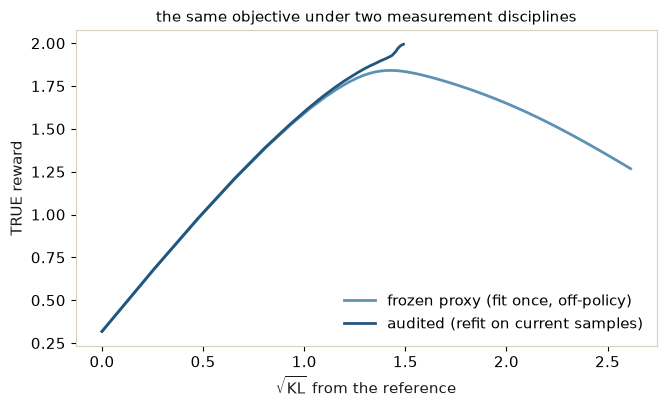

final true reward -- frozen: +1.268   audited: +1.994
re-measurement shrinks the exploitable error exactly where the policy is; that is the feature DPO trades away.


In [10]:
def ascend(beta, rounds=100, lr=0.4, audit_every=None):
    theta = np.log(pi_ref).copy()
    W, Lo = np.empty(0, int), np.empty(0, int)
    r_hat = r_phi                                  # start from the reference-fitted proxy
    traj = []
    for t in range(rounds):
        logp = theta - theta.max(); logp -= math.log(np.exp(logp).sum())
        p = np.exp(logp)
        if audit_every and t % audit_every == 0:
            w, l = sample_comparisons(1200, r_true, p, rng)   # fresh, on-policy audit
            W, Lo = np.concatenate([W, w]), np.concatenate([Lo, l])
            r_hat, _ = fit_reward(np.concatenate([winners, W]),
                                  np.concatenate([losers, Lo]), steps=2000)
        adv = r_hat - beta * (logp - np.log(pi_ref))
        theta += lr * (adv - p @ adv)          # mirror ascent: fixed point = the tilt
        traj.append((math.sqrt(KL(p, pi_ref)), p @ r_true))
    return np.array(traj)

BETA_LOOP = 0.05
frozen  = ascend(BETA_LOOP)
audited = ascend(BETA_LOOP, audit_every=5)

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot(*frozen.T,  color=STEEL,    lw=2, label="frozen proxy (fit once, off-policy)")
ax.plot(*audited.T, color=PRUSSIAN, lw=2, label="audited (refit on current samples)")
ax.set_xlabel("$\\sqrt{\\mathrm{KL}}$ from the reference"); ax.set_ylabel("TRUE reward")
ax.legend(frameon=False, loc="lower right")
ax.set_title("the same objective under two measurement disciplines", fontsize=11)
plt.tight_layout(); plt.show()
print(f"final true reward -- frozen: {frozen[-1,1]:+.3f}   audited: {audited[-1,1]:+.3f}")
print("re-measurement shrinks the exploitable error exactly where the policy is; "
      "that is the feature DPO trades away.")

## 8 · Optional: the same equations on a real model, still exact

Everything above generalizes to one honest place on a real LLM: the
**next-token distribution**. GPT-2's softmax head hands you the entire
$p(\cdot \mid \text{prefix})$ over 50k tokens in one forward pass — a fully
enumerable response space. So tilt it exactly with a transparent reward
(+1 for hedging vocabulary), price the KL, and run exact best-of-$n$ on it.
Set `RUN_HUGGINGFACE = True` in §1 (Colab: any runtime; ~500 MB download).

In [11]:
if RUN_HUGGINGFACE:
    import torch
    from transformers import GPT2LMHeadModel, GPT2TokenizerFast
    tok = GPT2TokenizerFast.from_pretrained("gpt2")
    model = GPT2LMHeadModel.from_pretrained("gpt2").eval()

    prompt = "The company's outlook for the coming year is"
    with torch.no_grad():
        logits = model(**tok(prompt, return_tensors="pt")).logits[0, -1]
    p_ref_t = torch.softmax(logits, -1).double().numpy()

    hedge_words = ["uncertain", "unclear", "mixed", "cautious", "difficult",
                   "challenging", "unpredictable", "volatile", "murky", "cloudy"]
    hedge_ids = [ids[0] for w in hedge_words
                 if len(ids := tok.encode(" " + w)) == 1]      # single-token only
    r_tok = np.zeros(len(p_ref_t)); r_tok[hedge_ids] = 1.0

    def tilt_t(beta):
        w = p_ref_t * np.exp(r_tok / beta); return w / w.sum()
    KL_t = lambda p, q: float(np.sum(np.where(p > 0, p * (np.log(p + 1e-300) - np.log(q + 1e-300)), 0)))

    print(f'prompt: "{prompt} ..."   hedge lexicon: {len(hedge_ids)} single-token words')
    for beta in (1.0, 0.3):
        pt = tilt_t(beta)
        print(f"\nbeta = {beta}: hedge mass {r_tok @ p_ref_t:.3f} -> {r_tok @ pt:.3f}, "
              f"measured KL = {KL_t(pt, p_ref_t):.3f} nats")
        for i in np.argsort(-pt)[:8]:
            print(f"   {pt[i]:.3f}  {tok.decode([i])!r}")

    order = np.argsort(r_tok + 1e-9 * rng.random(len(r_tok)), kind="stable")
    csum = np.cumsum(p_ref_t[order]); n = 16
    pb = np.empty_like(p_ref_t)
    pb[order] = csum**n - np.concatenate([[0.0], csum[:-1]])**n
    print(f"\nexact best-of-16 on the token distribution: KL = {KL_t(pb, p_ref_t):.3f} "
          f"vs ceiling {math.log(16) - 15/16:.3f} nats "
          "(far below: the reward is nearly flat -- ties waste selection)")
else:
    print("RUN_HUGGINGFACE = False -- skipping the GPT-2 section (set it in section 1).")

RUN_HUGGINGFACE = False -- skipping the GPT-2 section (set it in section 1).


## 9 · Carry it back to the deck

| Lecture frame | Here |
|---|---|
| Bradley–Terry (p. 23) | §2 — comparisons in, fitted index out; error where data is thin |
| The Gibbs tilt (p. 25) | §3 — built exactly, verified variationally |
| β prices the KL (p. 26) | §4 — one price, two distances; scale invariance |
| Goodhart (p. 33) | §5 — measured, with the turn marked; §5b the label-bias version |
| Best-of-$n$ ceiling (p. 32) | §6 — exact distribution, ceiling checked, common-currency plot |
| DPO (pp. 27–28, 34) | §7 — planted validation; §7b unmoored off-support |
| The PPO loop (p. 31) | §7c — frozen vs audited measurement, same objective |

**Knobs worth turning:** the number of comparisons in §2 (does the Goodhart
turn move right as the proxy improves?); the annotator bias in §5b; `n` in
§6; the pair-sampler in §7b (uniform coverage repairs the off-support cloud —
and is unbuyable in practice).

Everything here is stylized: an 8-word analyst, not a market. The point is
the *mechanism* — on a space small enough to enumerate, the lecture's
propositions stop being claims and become arithmetic.